# Laser Source Gradient Analysis

Calibration parameter sweep analysis using the `gradient_analysis` library.

In [1]:
import sys
sys.path.append('../')

from lucid.geometry import generate_detector
from lucid.losses import WC_smooth_loss
from lucid.simulation import setup_event_simulator
from lucid.detector_params import DetectorParams, laser_source
from lucid.gradient_analysis import (
    SweepParam, sweep_1d, sweep_2d, plot_sweep_1d, plot_sweep_2d,
)

from lucid.AbsorptionSIREN.siren_loader import setup_siren

import jax
import jax.numpy as jnp
from jax import jit, value_and_grad

In [2]:
default_json_filename = '../config/SK_geom_config.json'
detector = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)
NUM_DETECTORS = len(detector_points)

Nphot = 500_000
K = 8
Nphot_True = 15_000_000
K_True = 12

siren_model, siren_params = setup_siren('../lucid/AbsorptionSIREN/siren_params.npz')

# Explicit physical values for scalar-mode calibration
TRUE_PARAMS = DetectorParams(
    scatter_length=jnp.array(50.0),
    wall_reflection_rate=jnp.array(0.2),
    sensor_reflection_rate=jnp.array(0.2),
    absorption_length=jnp.array(50.0),
    qe=jnp.array(0.065),
    qe_corrections=jnp.ones(NUM_DETECTORS),
    #siren_params=siren_params,
)

source = laser_source(position=[0.0, 0.0, detector.H / 2 - 0.1], intensity=100_000_000)

simulate_event = setup_event_simulator(
    default_json_filename, Nphot, temperature=None, K=K,
    is_data=False, is_calibration=True, hit_mode='aggregated',
    wavelength_mode=False,
    #siren_params=siren_params, siren_N_evals=5,
)
simulate_data = setup_event_simulator(
    default_json_filename, Nphot_True, temperature=None, K=K_True,
    is_data=False, is_calibration=True, hit_mode='aggregated',
    default_detector_params=TRUE_PARAMS,
    wavelength_mode=False,
    #siren_params=siren_params, siren_N_evals=5,
)

key = jax.random.PRNGKey(42)
key_source, key_data = jax.random.split(key)
true_data = jax.lax.stop_gradient(simulate_data(source, key_data))

[siren_loader] Parameters loaded from ../lucid/AbsorptionSIREN/siren_params.npz


In [3]:
calib_sweeps = [
    SweepParam('Scatter Length',    'scatter_length',         half_width=20.0,  unit='m', min_val=0.001, grad_scale=100.0),
    SweepParam('Wall Reflection',   'wall_reflection_rate',   half_width=0.15,  min_val=0.0, max_val=1.0, grad_scale=0.1),
    SweepParam('Sensor Reflection', 'sensor_reflection_rate', half_width=0.08,  min_val=0.0, max_val=1.0, grad_scale=0.1),
    SweepParam('Absorption Length', 'absorption_length',      half_width=80.0,  unit='m', min_val=25.0, grad_scale=100.0), # Add min because any smaller and it blows up
]

In [4]:
@jit
def loss_and_grad_fn(detector_params):
    def loss_fn(dp):
        simulated_data = simulate_event(source, dp, key_source)
        return WC_smooth_loss(
            detector_points, *true_data, *simulated_data,
            lambda_poisson=1.0, lambda_time=0.0, tau=0.5,
        )
    return value_and_grad(loss_fn)(detector_params)

_ = loss_and_grad_fn(TRUE_PARAMS)  # warmup

In [5]:
results_1d = sweep_1d(loss_and_grad_fn, TRUE_PARAMS, calib_sweeps)

Absorption Length: 100%|████████████████████████████████████████████████████████████████| 41/41 [00:03<00:00, 10.89it/s]


(<Figure size 1600x700 with 8 Axes>,
 array([[<Axes: xlabel='Scatter Length (m)', ylabel='Loss'>,
         <Axes: xlabel='Wall Reflection', ylabel='Loss'>,
         <Axes: xlabel='Sensor Reflection', ylabel='Loss'>,
         <Axes: xlabel='Absorption Length (m)', ylabel='Loss'>],
        [<Axes: xlabel='Scatter Length (m)', ylabel='Gradient'>,
         <Axes: xlabel='Wall Reflection', ylabel='Gradient'>,
         <Axes: xlabel='Sensor Reflection', ylabel='Gradient'>,
         <Axes: xlabel='Absorption Length (m)', ylabel='Gradient'>]],
       dtype=object))

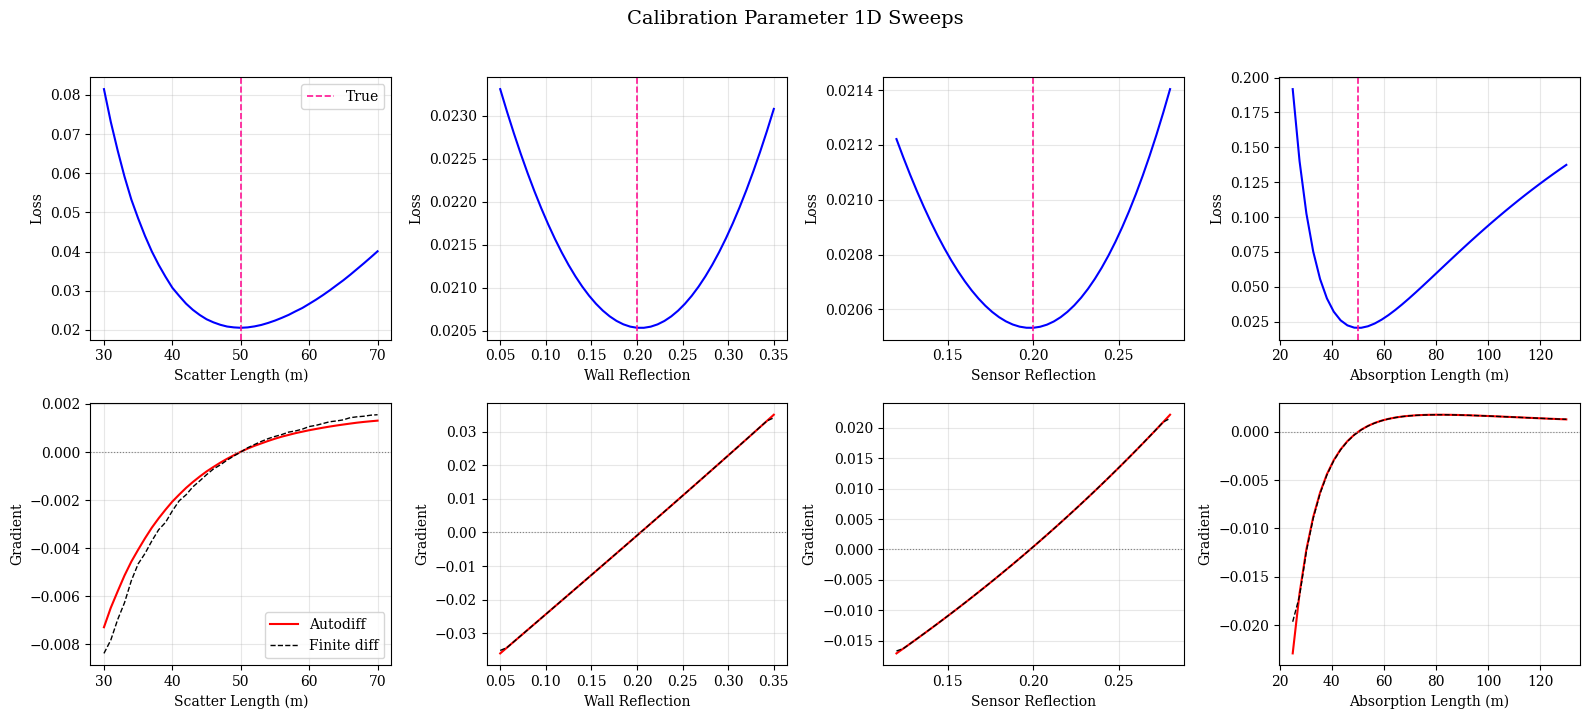

In [6]:
plot_sweep_1d(results_1d, title='Calibration Parameter 1D Sweeps', save_path='figures/laser_1d_sweeps_v3.png')

In [ ]:
pairs_2d = [
    (calib_sweeps[0], calib_sweeps[3], 31),  # Scatter Length x Absorption Length
    (calib_sweeps[1], calib_sweeps[2], 41),  # Wall Reflection x Sensor Reflection
    (calib_sweeps[0], calib_sweeps[1], 41),  # Scatter Length x Wall Reflection
    (calib_sweeps[0], calib_sweeps[2], 41),  # Scatter Length x Sensor Reflection
]
results_2d = [sweep_2d(loss_and_grad_fn, TRUE_PARAMS, px, py, num_points=n) for px, py, n in pairs_2d]

Wall Reflection x Sensor Reflection:   2%|█▏                                             | 1/41 [00:05<03:44,  5.62s/it]


KeyboardInterrupt: 

In [ ]:
plot_sweep_2d(results_2d, title='Calibration Parameter 2D Surfaces', save_path='figures/laser_2d_surfaces_v3.png')

In [ ]:
tt va bien il faut changer simulator pour le bail des vmap peut etre echanger les places des arguments fct et params

In [ ]:
Oui ça marche — tu mets absorption_siren_params avant absorption_function dans toutes les signatures :
pythondef photon_iteration_update_factors(
        position, direction, time, surface_distance,
        normal, scatter_length, wall_reflection_rate, sensor_reflection_rate,
        absorption_length,
        hit_sensor, rng_key, speed_of_light,
        absorption_siren_params=None,   # ← 13ème
        absorption_function=None,       # ← 14ème, pas passé au vmap
        N_evals=5):
Même swap dans photon_iteration_update_factors_safe, _fwd, et _bwd. Puis le vmap :
pythonin_axes=(0, 0, 0, 0, 0,
         0, None, None, 0,
         0, 0, None,
         None)   # absorption_siren_params seulement

)(... SPEED_OF_LIGHT_MATERIAL,
  absorption_siren_params)
absorption_function et N_evals restent en défaut dans la signature et sont capturés depuis la closure. C'est la solution la plus simple.